# Figure 3: Parameter decoding

Average partial \(R^2\) across acoustic parameters for core CochCNN9 models at `relu4`.
Loads pickles from `parameter_decoding_v2/`.

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib
import sys

sys.path.insert(0, str(Path("../").resolve()))
from importlib import reload
import figure_utils
reload(figure_utils)
from figure_utils import (
    format_model_str,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    set_bar_labels,
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)


## Load parameter decoding results

In [2]:
def get_results_from_dict(results_dict):
    row_records = []
    for score_type, score_dict in results_dict.items():
        if "scores" in score_type:
            for parameter, param_dict in score_dict.items():
                for fold_idx, score in enumerate(param_dict["values"]):
                    row_records.append({
                        "parameter": parameter,
                        "score_type": score_type,
                        "score": score,
                        "fold": fold_idx,
                    })
    return row_records


param_decoding_results_dir = Path("parameter_decoding_v2")
results_pkls = list(param_decoding_results_dir.rglob("*kell*/*_r2_decoding_values*.pkl"))

results_dfs = []
for file_path in results_pkls:
    results_dict = pd.read_pickle(file_path)
    results_df = pd.DataFrame(get_results_from_dict(results_dict))
    results_df["layer"] = file_path.stem.split("_r2")[0]
    model_name, arch, _, eq_lmbda = format_model_str(file_path)
    results_df["model_name"] = model_name
    results_df["model"] = arch
    results_df["eq_lmbda"] = eq_lmbda if eq_lmbda else ""
    results_dfs.append(results_df)

results = pd.concat(results_dfs, axis=0, ignore_index=True).drop_duplicates()
id_cols = ["parameter", "layer", "model_name", "model", "eq_lmbda", "fold"]
results = results.pivot(index=id_cols, columns="score_type", values="score").reset_index()

all_models_in_data = results["model_name"].unique()
model_plot_order = [m for m in get_standard_hue_order() if m in all_models_in_data]
model_plot_order += [m for m in all_models_in_data if m not in model_plot_order]
palette_dict = build_model_palette(model_plot_order, get_standard_base_colors())


## Core models (average over parameters)

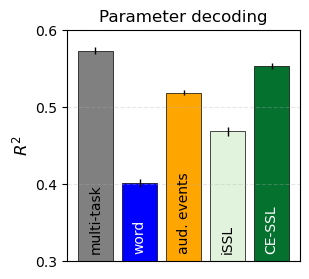

In [3]:
plot_model_order = [
    "CochCNN9 supervised multi-task",
    "CochCNN9 supervised word",
    "CochCNN9 supervised audioset",
    "CochCNN9 ssl λ=0.0",
    "CochCNN9 ssl λ=0.5",
]

for_plot = results[results.model_name.isin(plot_model_order) & (results.layer == "relu4")]
model_order = [m for m in model_plot_order if m in for_plot["model_name"].unique()]

run_means = for_plot.groupby(["model_name", "fold"])["pr2_scores"].mean().reset_index()
run_means = run_means.rename(columns={"pr2_scores": "mean_r2_per_run"})
avg_data = run_means.groupby("model_name")["mean_r2_per_run"].agg(["mean", "std"]).reset_index()
avg_data.columns = ["model_name", "mean_r2", "std_r2"]

available_models = [m for m in model_order if m in avg_data["model_name"].values]
avg_data = avg_data.set_index("model_name").loc[available_models].reset_index()

panel_size = 3
fig, ax = plt.subplots(1, 1, figsize=(panel_size, panel_size))
x_pos = np.arange(len(available_models))

bars = ax.bar(
    x_pos,
    avg_data["mean_r2"].values,
    color=[palette_dict[m] for m in available_models],
    edgecolor="black",
    linewidth=0.5,
)
ax.errorbar(
    x_pos,
    avg_data["mean_r2"].values,
    yerr=avg_data["std_r2"].values,
    fmt="none",
    color="black",
    capsize=0,
    capthick=1,
    elinewidth=1,
)

set_bar_labels(
    ax,
    bars,
    [model_label(m, use_ssl_names=True).replace("supervised ", "") for m in available_models],
    white_text_substrs=["word", "CE"],
    ymin_bars=0.31,
    no_olap_pad=0.025,
    fontsize=10,
    sem_vals=avg_data["std_r2"].values,
)

ax.set_xticks([])
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_ylabel("$R^2$", fontsize=12)
ax.set_title("Parameter decoding")
ax.set_ylim(0.3, 0.6)
ax.set_yticks(np.linspace(0.3, 0.6, 4))

# plt.savefig(fig_out_dir / "avg_param_decoding_core_models.pdf", bbox_inches="tight")
